<a href="https://colab.research.google.com/github/ibrahimbarghout/robust-ecg-domain-generalization/blob/main/notebooks/02_data_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.9 MB/s eta 0:00:00


In [3]:
import wfdb
print("WFDB version:", wfdb.__version__)

WFDB version: 4.3.1


In [4]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles currently here:")
print(os.listdir())

Current directory:
/content

Files currently here:
['.config', 'sample_data']


In [5]:
import os

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Data directory:", DATA_DIR)

Data directory: /content/data


In [10]:
import wfdb
import os

DATA_DIR = "/content/data/ptb-xl"

os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading PTB-XL 1.0.3...")

In [11]:
import wfdb
import os

DATA_DIR = "/content/data/ptb-xl"
os.makedirs(DATA_DIR, exist_ok=True)

wfdb.dl_database(
    "ptb-xl",
    dl_dir=DATA_DIR
)

Streaming output truncated to the last 5000 lines.
Generating list of all files for: records100/16000/16837_lr
Generating list of all files for: records100/16000/16838_lr
Generating list of all files for: records100/16000/16839_lr
Generating list of all files for: records100/16000/16840_lr
Generating list of all files for: records100/16000/16841_lr
Generating list of all files for: records100/16000/16842_lr
Generating list of all files for: records100/16000/16843_lr
Generating list of all files for: records100/16000/16844_lr
Generating list of all files for: records100/16000/16845_lr
Generating list of all files for: records100/16000/16846_lr
Generating list of all files for: records100/16000/16847_lr
Generating list of all files for: records100/16000/16848_lr
Generating list of all files for: records100/16000/16849_lr
Generating list of all files for: records100/16000/16850_lr
Generating list of all files for: records100/16000/16851_lr
Generating list of all files for: records100/1600

NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/21000/21837_lrrecords500/00000/00001_hr.hea

In [12]:
!wget -r -N -c -np https://physionet.org/files/ptb-xl/1.0.3/ -P /content/data/

Streaming output truncated to the last 5000 lines.
2026-08-20 16:05:43 (149 KB/s) - ‘/content/data/physionet.org/files/ptb-xl/1.0.3/records500/07000/07248_hr.dat’ saved [120000/120000]

--2026-08-20 16:05:43--  https://physionet.org/files/ptb-xl/1.0.3/records500/07000/07248_hr.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 602 [text/plain]
Saving to: ‘/content/data/physionet.org/files/ptb-xl/1.0.3/records500/07000/07248_hr.hea’

physionet.org/files 100%[===================>]     602  --.-KB/s    in 0s      

2026-08-20 16:05:44 (369 MB/s) - ‘/content/data/physionet.org/files/ptb-xl/1.0.3/records500/07000/07248_hr.hea’ saved [602/602]

--2026-08-20 16:05:44--  https://physionet.org/files/ptb-xl/1.0.3/records500/07000/07249_hr.dat
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 120000 (117K) [application/octet-stream]
Saving to: ‘/content/data/physionet.org/files/ptb-xl/

In [14]:
!wget -c -O /content/data/ptb-xl-1.0.3.zip \
"https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"

--2026-08-20 19:50:28--  https://physionet.org/static/published-projects/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://physionet.org/content/ptb-xl/get-zip/1.0.3/ [following]
--2026-08-20 19:50:29--  https://physionet.org/content/ptb-xl/get-zip/1.0.3/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [15]:
!ls -lh /content/data/ptb-xl-1.0.3.zip

-rw-r--r-- 1 root root 1.8G Nov  9  2022 /content/data/ptb-xl-1.0.3.zip


In [16]:
!unzip -t /content/data/ptb-xl-1.0.3.zip | tail -5

    testing: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/21000/21836_hr.hea   OK
    testing: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/21000/21837_hr.dat   OK
    testing: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/21000/21837_hr.hea   OK
    testing: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv   OK
No errors detected in compressed data of /content/data/ptb-xl-1.0.3.zip.


In [18]:
!unzip -q /content/data/ptb-xl-1.0.3.zip -d /content/data/

In [19]:
!ls -lh /content/data/

total 1.8G
drwxr-xr-x 3 root root 4.0K Aug 20 12:28 physionet.org
drwxr-xr-x 2 root root 4.0K Aug 20 11:46 ptb-xl
-rw-r--r-- 1 root root 1.8G Nov  9  2022 ptb-xl-1.0.3.zip
drwxr-xr-x 4 root root 4.0K Aug 20 20:09 ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [20]:
!find /content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3 -maxdepth 2 -type f | head -30

/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/LICENSE.txt
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_v103_changelog.txt
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/example_physionet.py
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/SHA256SUMS.txt
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/RECORDS
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv
/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_v102_changelog.txt


In [21]:
import pandas as pd

data_path = "/content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

df = pd.read_csv(f"{data_path}/ptbxl_database.csv")

print("Number of ECG records:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

Number of ECG records: 21799
Number of columns: 28

Columns:
['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']


In [22]:
from ast import literal_eval
from collections import Counter

# Convert the text representation into Python dictionaries
scp_codes = df["scp_codes"].apply(literal_eval)

# Count how often each SCP code appears
code_counts = Counter()

for codes in scp_codes:
    code_counts.update(codes.keys())

print("Number of unique SCP codes:", len(code_counts))
print("\nMost common diagnostic codes:")
for code, count in code_counts.most_common(30):
    print(f"{code}: {count}")

Number of unique SCP codes: 71

Most common diagnostic codes:
SR: 16748
NORM: 9514
ABQRS: 3327
IMI: 2676
ASMI: 2357
LVH: 2132
NDT: 1825
LAFB: 1623
AFIB: 1514
ISC_: 1272
PVC: 1143
IRBBB: 1118
STD_: 1009
VCLVH: 875
STACH: 826
1AVB: 793
IVCD: 787
SARRH: 772
NST_: 767
ISCAL: 659
SBRAD: 637
QWAVE: 548
CRBBB: 541
CLBBB: 536
ILMI: 478
LOWT: 438
LAO/LAE: 426
NT_: 423
PAC: 398
AMI: 353


In [23]:
scp = pd.read_csv(f"{data_path}/scp_statements.csv")

print("Number of SCP statements:", len(scp))
print("\nColumns:")
print(scp.columns.tolist())

print("\nFirst 20 rows:")
display(scp.head(20))

Number of SCP statements: 71

Columns:
['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']

First 20 rows:


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
5,IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
6,ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
7,LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
8,LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
9,ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [26]:
print(scp[["description", "diagnostic", "diagnostic_class", "diagnostic_subclass"]].to_string(index=False))

                                                 description  diagnostic diagnostic_class diagnostic_subclass
                              non-diagnostic T abnormalities         1.0             STTC                STTC
                                     non-specific ST changes         1.0             STTC                NST_
                                            digitalis-effect         1.0             STTC                STTC
                                            long QT-interval         1.0             STTC                STTC
                                                  normal ECG         1.0             NORM                NORM
                              inferior myocardial infarction         1.0               MI                 IMI
                          anteroseptal myocardial infarction         1.0               MI                 AMI
                                left ventricular hypertrophy         1.0              HYP                 LVH
          

In [29]:
# Correct mapping: SCP code -> diagnostic class

code_to_class = dict(
    zip(
        scp["Unnamed: 0"].astype(str),
        scp["diagnostic_class"]
    )
)

# Verify the mapping
print("Example mappings:\n")

for code in ["NORM", "IMI", "ASMI", "LVH", "LAFB", "AFIB", "PVC"]:
    print(f"{code} → {code_to_class.get(code, 'NOT FOUND')}")

Example mappings:

NORM → NORM
IMI → MI
ASMI → MI
LVH → HYP
LAFB → CD
AFIB → nan
PVC → nan


In [30]:
class_counts = Counter()

for codes in scp_codes:
    classes_for_ecg = set()

    for code in codes:
        diagnostic_class = code_to_class.get(code)

        if pd.notna(diagnostic_class):
            classes_for_ecg.add(diagnostic_class)

    for cls in classes_for_ecg:
        class_counts[cls] += 1

print("ECGs containing each diagnostic class:\n")

for cls, count in class_counts.most_common():
    percentage = count / len(df) * 100
    print(f"{cls}: {count:,} ({percentage:.1f}%)")

ECGs containing each diagnostic class:

NORM: 9,514 (43.6%)
MI: 5,469 (25.1%)
STTC: 5,235 (24.0%)
CD: 4,898 (22.5%)
HYP: 2,649 (12.2%)


In [31]:
validation_columns = [
    "validated_by",
    "second_opinion",
    "validated_by_human",
    "initial_autogenerated_report"
]

for col in validation_columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== validated_by =====
validated_by
NaN     9378
0.0     6120
1.0     5127
2.0      566
3.0      175
4.0      115
6.0      100
5.0       90
7.0       75
8.0       37
9.0        9
10.0       6
11.0       1
Name: count, dtype: int64

===== second_opinion =====
second_opinion
False    21244
True       555
Name: count, dtype: int64

===== validated_by_human =====
validated_by_human
True     16056
False     5743
Name: count, dtype: int64

===== initial_autogenerated_report =====
initial_autogenerated_report
False    14986
True      6813
Name: count, dtype: int64


In [32]:
print("Total ECG recordings:", len(df))
print("Unique patients:", df["patient_id"].nunique())

ecgs_per_patient = df.groupby("patient_id").size()

print("\nECGs per patient:")
print(ecgs_per_patient.describe())

print("\nPatients with multiple ECGs:",
      (ecgs_per_patient > 1).sum())

print("Maximum ECGs from one patient:",
      ecgs_per_patient.max())

Total ECG recordings: 21799
Unique patients: 18869

ECGs per patient:
count    18869.000000
mean         1.155281
std          0.523105
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
dtype: float64

Patients with multiple ECGs: 2111
Maximum ECGs from one patient: 10


In [33]:
print("Stratified fold distribution:\n")
print(df["strat_fold"].value_counts().sort_index())

print("\nNumber of unique patients per fold:\n")
print(
    df.groupby("strat_fold")["patient_id"]
      .nunique()
      .sort_index()
)

Stratified fold distribution:

strat_fold
1     2175
2     2181
3     2192
4     2174
5     2174
6     2173
7     2176
8     2173
9     2183
10    2198
Name: count, dtype: int64

Number of unique patients per fold:

strat_fold
1     1878
2     1849
3     1887
4     1883
5     1890
6     1884
7     1871
8     1881
9     1942
10    1904
Name: patient_id, dtype: int64


In [34]:
patient_fold_counts = df.groupby("patient_id")["strat_fold"].nunique()

print("Patients appearing in more than one fold:",
      (patient_fold_counts > 1).sum())

print("\nMaximum number of folds containing the same patient:",
      patient_fold_counts.max())

Patients appearing in more than one fold: 0

Maximum number of folds containing the same patient: 1


In [35]:
!pip install -q wfdb

In [36]:
import wfdb
import os

# Get the first ECG's relative file path
record_path = os.path.join(
    data_path,
    df.iloc[0]["filename_lr"]
)

print("ECG ID:", df.iloc[0]["ecg_id"])
print("Patient ID:", df.iloc[0]["patient_id"])
print("Record path:", record_path)

# Load the ECG
record = wfdb.rdrecord(record_path)

print("\nSignal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs, "Hz")
print("Number of leads:", record.n_sig)
print("Lead names:", record.sig_name)

ECG ID: 1
Patient ID: 15709.0
Record path: /content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00001_lr

Signal shape: (1000, 12)
Sampling frequency: 100 Hz
Number of leads: 12
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


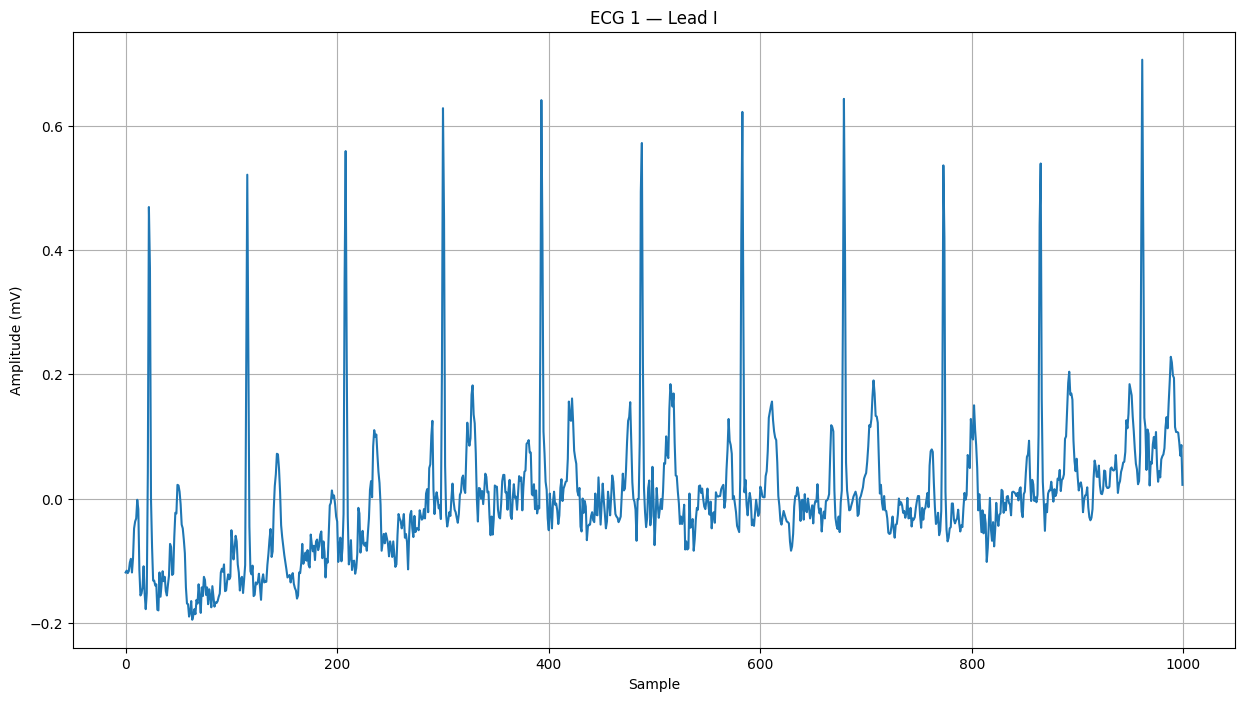

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

time = record.p_signal[:, 0] * 0  # placeholder for time axis
time = range(record.p_signal.shape[0])

plt.plot(time, record.p_signal[:, 0])

plt.title(f"ECG {df.iloc[0]['ecg_id']} — Lead I")
plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.grid(True)

plt.show()

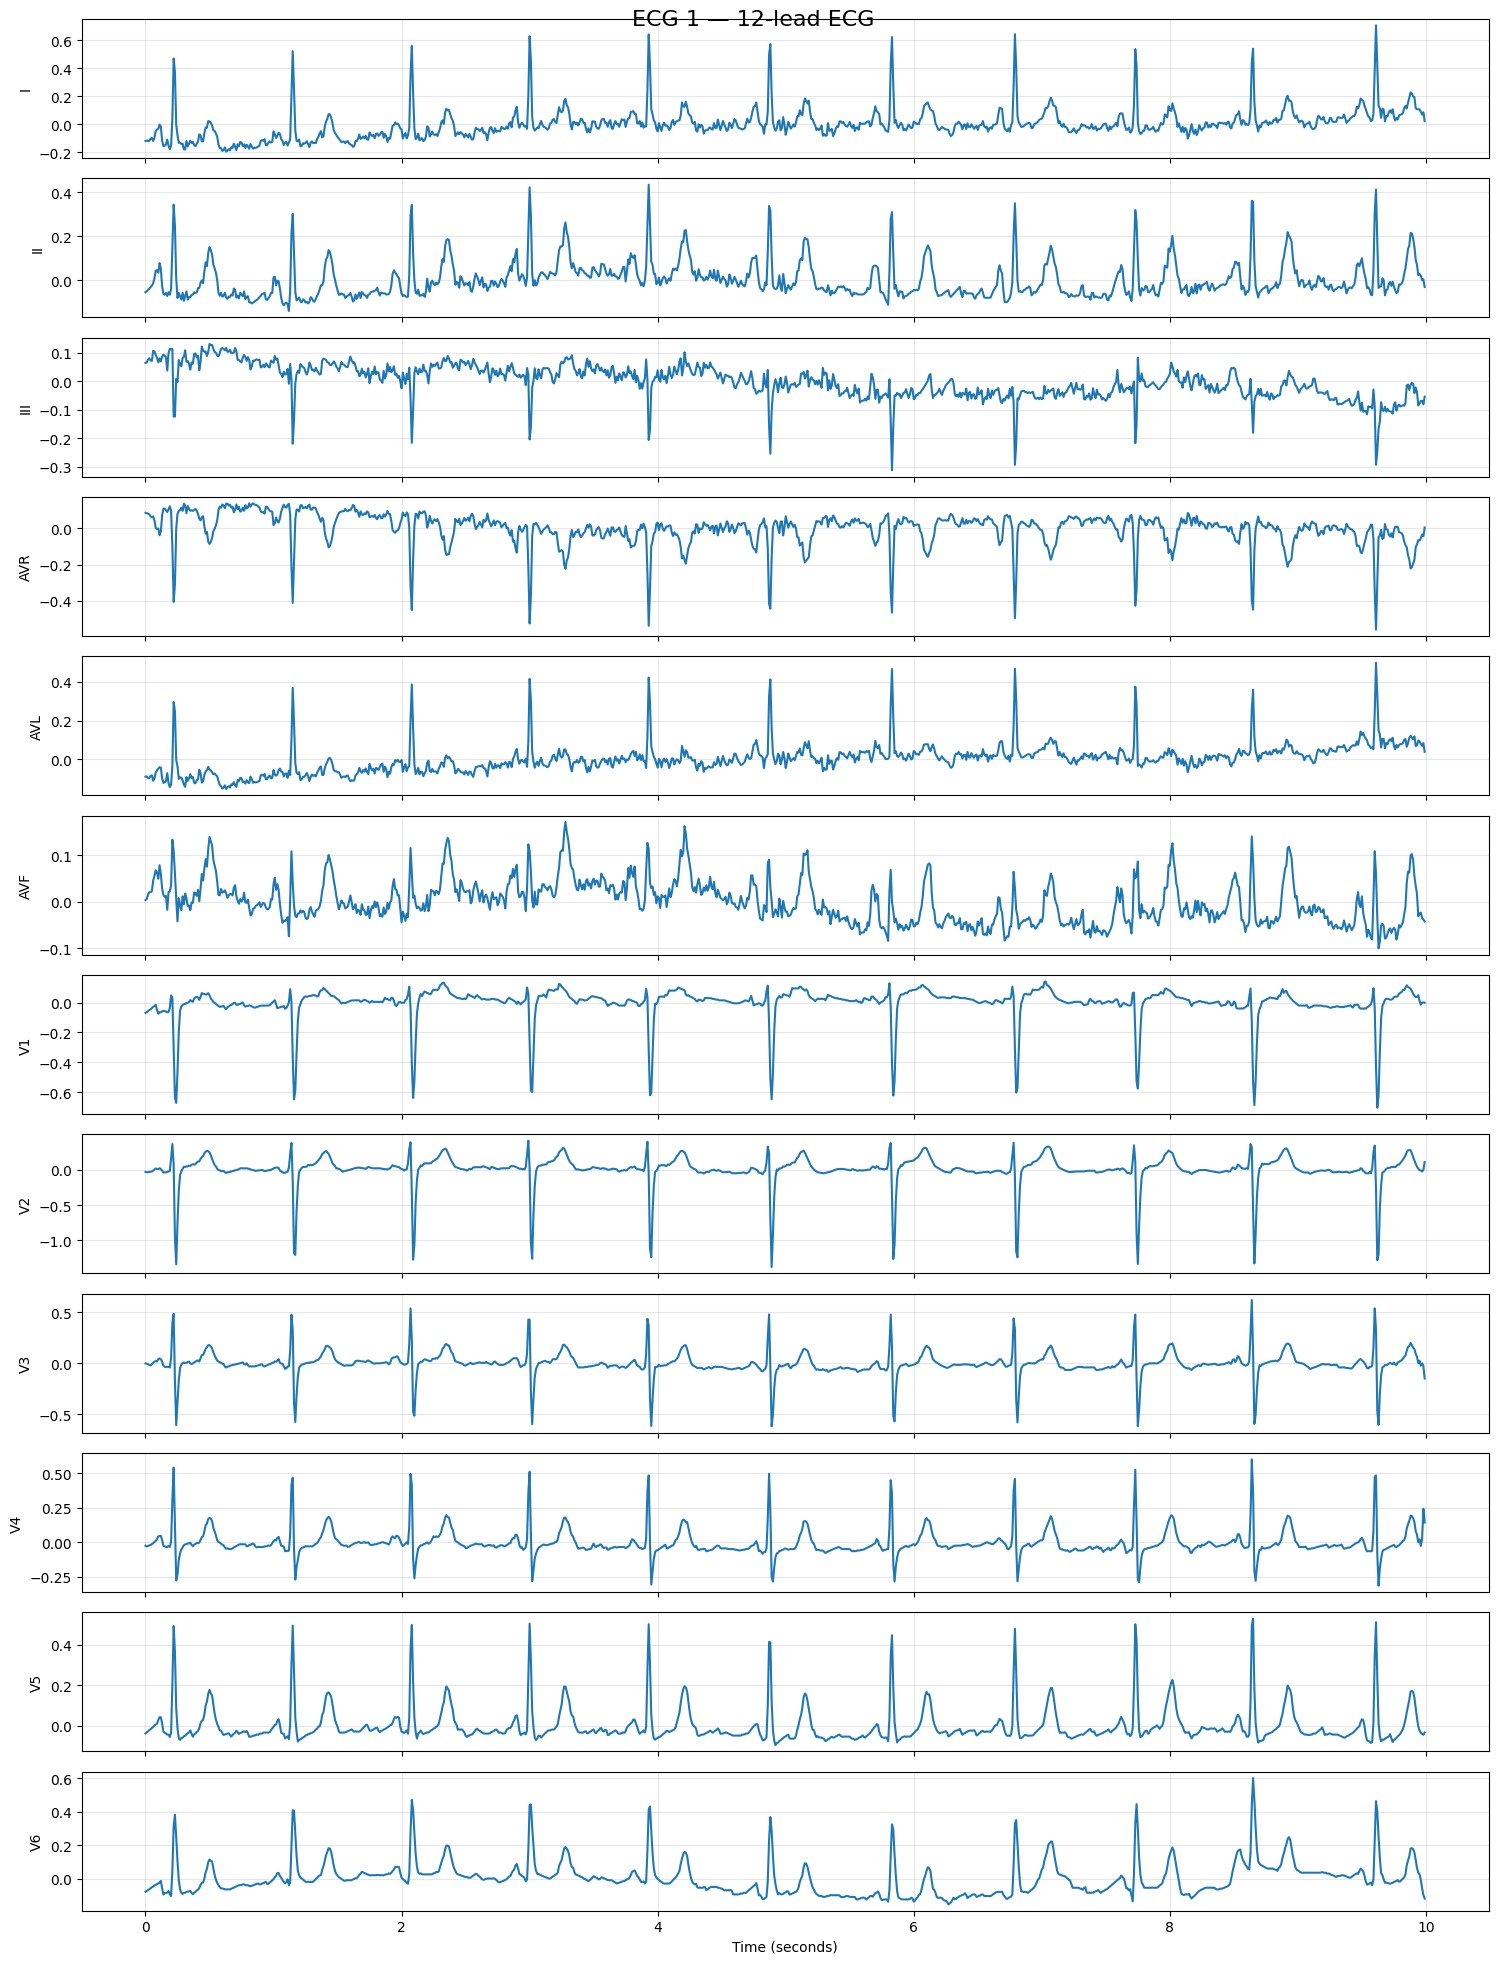

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Create a time axis in seconds
time = np.arange(record.p_signal.shape[0]) / record.fs

fig, axes = plt.subplots(12, 1, figsize=(15, 20), sharex=True)

for i, lead in enumerate(record.sig_name):
    axes[i].plot(time, record.p_signal[:, i])
    axes[i].set_ylabel(lead)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"ECG {df.iloc[0]['ecg_id']} — 12-lead ECG", fontsize=16)

plt.tight_layout()
plt.show()

In [39]:
first_ecg = df.iloc[0]

print("ECG ID:", first_ecg["ecg_id"])
print("Patient ID:", first_ecg["patient_id"])
print("Age:", first_ecg["age"])
print("Sex:", first_ecg["sex"])

print("\nSCP codes:")
print(first_ecg["scp_codes"])

print("\nReport:")
print(first_ecg["report"])

print("\nHuman validated:", first_ecg["validated_by_human"])
print("Second opinion:", first_ecg["second_opinion"])

ECG ID: 1
Patient ID: 15709.0
Age: 56.0
Sex: 1

SCP codes:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}

Report:
sinusrhythmus periphere niederspannung

Human validated: True
Second opinion: False


In [40]:
import numpy as np

signal = record.p_signal

print("Overall signal statistics:")
print("Minimum:", np.min(signal), "mV")
print("Maximum:", np.max(signal), "mV")
print("Mean:", np.mean(signal), "mV")
print("Standard deviation:", np.std(signal), "mV")

print("\nStatistics by lead:")

for i, lead in enumerate(record.sig_name):
    lead_signal = signal[:, i]

    print(
        f"{lead:>4}: "
        f"min={lead_signal.min(): .3f} mV, "
        f"max={lead_signal.max(): .3f} mV, "
        f"mean={lead_signal.mean(): .3f} mV, "
        f"std={lead_signal.std(): .3f} mV"
    )

Overall signal statistics:
Minimum: -1.377 mV
Maximum: 0.706 mV
Mean: 0.00010475000000000072 mV
Standard deviation: 0.1076345473230482 mV

Statistics by lead:
   I: min=-0.195 mV, max= 0.706 mV, mean= 0.002 mV, std= 0.109 mV
  II: min=-0.140 mV, max= 0.435 mV, mean= 0.001 mV, std= 0.083 mV
 III: min=-0.312 mV, max= 0.130 mV, mean=-0.001 mV, std= 0.059 mV
 AVR: min=-0.559 mV, max= 0.138 mV, mean=-0.001 mV, std= 0.092 mV
 AVL: min=-0.155 mV, max= 0.500 mV, mean= 0.001 mV, std= 0.077 mV
 AVF: min=-0.100 mV, max= 0.172 mV, mean= 0.000 mV, std= 0.047 mV
  V1: min=-0.704 mV, max= 0.142 mV, mean=-0.002 mV, std= 0.113 mV
  V2: min=-1.377 mV, max= 0.410 mV, mean= 0.007 mV, std= 0.214 mV
  V3: min=-0.618 mV, max= 0.620 mV, mean=-0.002 mV, std= 0.118 mV
  V4: min=-0.315 mV, max= 0.599 mV, mean=-0.004 mV, std= 0.095 mV
  V5: min=-0.097 mV, max= 0.530 mV, mean=-0.001 mV, std= 0.089 mV
  V6: min=-0.155 mV, max= 0.602 mV, mean= 0.001 mV, std= 0.102 mV


In [41]:
quality_columns = [
    "baseline_drift",
    "static_noise",
    "burst_noise",
    "electrodes_problems",
    "extra_beats",
    "pacemaker"
]

for col in quality_columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== baseline_drift =====
baseline_drift
NaN               20201
 , V6               221
 , V1                94
 , II-AVF            60
 , V3                59
                  ...  
 , III,AVL,V3         1
 , III,AVR,AVF        1
 , II-AVF,V5          1
 , AVR,AVF,V3         1
 , III,V3,V6          1
Name: count, Length: 318, dtype: int64

===== static_noise =====
static_noise
NaN                   18539
 , I-AVR,               953
 , I-AVF,               919
 , alles,               522
 , I-V1,                156
                      ...  
 , I,V4,                  1
 , I.II,                  1
 , III,AVL,               1
 , I,II,AVL,AVF,          1
 , I-V1,V6,               1
Name: count, Length: 125, dtype: int64

===== burst_noise =====
burst_noise
NaN             21186
alles             140
I-AVF              47
V1                 46
V1,V2              28
                ...  
I,III-AVL           1
I,II,AVR            1
II-AVL              1
V1,V4               1
II-AVL,V1,V

In [42]:
print("ECGs with recorded quality/artifact annotations:\n")

for col in quality_columns:
    count = df[col].notna().sum()
    percentage = count / len(df) * 100

    print(
        f"{col:20s}: "
        f"{count:5,} ECGs "
        f"({percentage:5.1f}%)"
    )

ECGs with recorded quality/artifact annotations:

baseline_drift      : 1,598 ECGs (  7.3%)
static_noise        : 3,260 ECGs ( 15.0%)
burst_noise         :   613 ECGs (  2.8%)
electrodes_problems :    30 ECGs (  0.1%)
extra_beats         : 1,949 ECGs (  8.9%)
pacemaker           :   291 ECGs (  1.3%)


In [43]:
# Identify SCP codes that are rhythm annotations
rhythm_codes = set(
    scp.loc[scp["rhythm"].notna(), "Unnamed: 0"].astype(str)
)

rhythm_counts = Counter()

for codes in scp_codes:
    for code in codes:
        if code in rhythm_codes:
            rhythm_counts[code] += 1

print("Rhythm annotations:\n")

for code, count in rhythm_counts.most_common():
    description = scp.loc[
        scp["Unnamed: 0"].astype(str) == code,
        "description"
    ].iloc[0]

    percentage = count / len(df) * 100

    print(
        f"{code:8s} "
        f"{count:5,} "
        f"({percentage:5.1f}%)  "
        f"{description}"
    )

Rhythm annotations:

SR       16,748 ( 76.8%)  sinus rhythm
AFIB     1,514 (  6.9%)  atrial fibrillation
STACH      826 (  3.8%)  sinus tachycardia
SARRH      772 (  3.5%)  sinus arrhythmia
SBRAD      637 (  2.9%)  sinus bradycardia
PACE       294 (  1.3%)  normal functioning artificial pacemaker
SVARR      157 (  0.7%)  supraventricular arrhythmia
BIGU        82 (  0.4%)  bigeminal pattern (unknown origin, SV or Ventricular)
AFLT        73 (  0.3%)  atrial flutter
SVTAC       27 (  0.1%)  supraventricular tachycardia
PSVT        24 (  0.1%)  paroxysmal supraventricular tachycardia
TRIGU       20 (  0.1%)  trigeminal pattern (unknown origin, SV or Ventricular)


In [44]:
# Number of SCP annotations attached to each ECG
num_labels = scp_codes.apply(len)

print("Number of SCP labels per ECG:\n")
print(num_labels.describe())

print("\nExact distribution:\n")
print(num_labels.value_counts().sort_index())

print("\nPercentage of ECGs with multiple labels:",
      (num_labels > 1).mean() * 100)

Number of SCP labels per ECG:

count    21799.000000
mean         2.798615
std          1.211884
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          9.000000
Name: scp_codes, dtype: float64

Exact distribution:

scp_codes
1      709
2    11225
3     5101
4     2594
5     1251
6      596
7      253
8       63
9        7
Name: count, dtype: int64

Percentage of ECGs with multiple labels: 96.74755722739576


In [45]:
from collections import Counter
from itertools import combinations

pair_counts = Counter()

for codes in scp_codes:
    # Only use the actual SCP codes
    code_list = sorted(codes.keys())

    # Generate every pair of labels on this ECG
    for pair in combinations(code_list, 2):
        pair_counts[pair] += 1

print("Most common SCP label combinations:\n")

for (code1, code2), count in pair_counts.most_common(30):
    print(f"{code1:8s} + {code2:8s}: {count:,}")

Most common SCP label combinations:

NORM     + SR      : 8,204
ABQRS    + SR      : 2,534
IMI      + SR      : 1,980
ASMI     + SR      : 1,574
LVH      + SR      : 1,518
ABQRS    + IMI     : 1,477
NDT      + SR      : 1,381
LAFB     + SR      : 1,233
ISC_     + LVH     : 1,169
ABQRS    + ASMI    : 1,160
IRBBB    + SR      : 832
ISC_     + SR      : 795
SR       + VCLVH   : 703
SR       + STD_    : 681
LVH      + VCLVH   : 653
1AVB     + SR      : 602
ASMI     + IMI     : 588
PVC      + SR      : 587
IVCD     + SR      : 572
ASMI     + LAFB    : 518
QWAVE    + SR      : 449
ISCAL    + SR      : 429
NORM     + SARRH   : 427
NST_     + SR      : 393
LVH      + STD_    : 382
CLBBB    + SR      : 371
ILMI     + SR      : 369
AFIB     + ASMI    : 368
CRBBB    + SR      : 364
NT_      + SR      : 364


In [46]:
# Create a clinically grouped label representation

diagnostic_groups = {
    "NORM": {"NORM"},
    "MI": {"MI"},
    "STTC": {"STTC"},
    "CD": {"CD"},
    "HYP": {"HYP"}
}

# Build code -> class mapping
code_to_class = dict(
    zip(
        scp["Unnamed: 0"].astype(str),
        scp["diagnostic_class"]
    )
)

# Build code -> rhythm mapping
code_to_rhythm = dict(
    zip(
        scp["Unnamed: 0"].astype(str),
        scp["rhythm"]
    )
)

# Count ECGs with each grouped category
group_counts = Counter()

for codes in scp_codes:

    # Diagnostic groups
    present_classes = {
        code_to_class.get(code)
        for code in codes
        if pd.notna(code_to_class.get(code))
    }

    for group in ["NORM", "MI", "STTC", "CD", "HYP"]:
        if group in present_classes:
            group_counts[group] += 1

    # Rhythm labels
    for code in codes:
        if pd.notna(code_to_rhythm.get(code)):
            group_counts[code] += 1

print("Grouped diagnostic counts:\n")

for group in ["NORM", "MI", "STTC", "CD", "HYP"]:
    count = group_counts[group]
    print(f"{group:6s}: {count:,} ({count / len(df) * 100:.1f}%)")

print("\nSelected rhythm counts:\n")

for rhythm in ["AFIB", "PVC", "STACH", "SBRAD", "AFLT", "SVARR"]:
    count = group_counts[rhythm]
    print(f"{rhythm:6s}: {count:,} ({count / len(df) * 100:.1f}%)")

Grouped diagnostic counts:

NORM  : 9,514 (43.6%)
MI    : 5,469 (25.1%)
STTC  : 5,235 (24.0%)
CD    : 4,898 (22.5%)
HYP   : 2,649 (12.2%)

Selected rhythm counts:

AFIB  : 1,514 (6.9%)
PVC   : 0 (0.0%)
STACH : 826 (3.8%)
SBRAD : 637 (2.9%)
AFLT  : 73 (0.3%)
SVARR : 157 (0.7%)


In [47]:
# Rhythm codes identified in PTB-XL
rhythm_codes = {
    "SR",
    "AFIB",
    "STACH",
    "SARRH",
    "SBRAD",
    "PACE",
    "SVARR",
    "BIGU",
    "AFLT",
    "SVTAC",
    "PSVT",
    "TRIGU",
    "PVC",
    "PAC",
    "VES"
}

rhythm_counts = Counter()

for codes in scp_codes:
    for code in codes:
        if code in rhythm_codes:
            rhythm_counts[code] += 1

print("Rhythm annotations:\n")

for code, count in rhythm_counts.most_common():
    description = scp.loc[
        scp["Unnamed: 0"].astype(str) == code,
        "description"
    ].iloc[0]

    percentage = count / len(df) * 100

    print(
        f"{code:6s}: "
        f"{count:5,} "
        f"({percentage:5.1f}%)  "
        f"{description}"
    )

Rhythm annotations:

SR    : 16,748 ( 76.8%)  sinus rhythm
AFIB  : 1,514 (  6.9%)  atrial fibrillation
PVC   : 1,143 (  5.2%)  ventricular premature complex
STACH :   826 (  3.8%)  sinus tachycardia
SARRH :   772 (  3.5%)  sinus arrhythmia
SBRAD :   637 (  2.9%)  sinus bradycardia
PAC   :   398 (  1.8%)  atrial premature complex
PACE  :   294 (  1.3%)  normal functioning artificial pacemaker
SVARR :   157 (  0.7%)  supraventricular arrhythmia
BIGU  :    82 (  0.4%)  bigeminal pattern (unknown origin, SV or Ventricular)
AFLT  :    73 (  0.3%)  atrial flutter
SVTAC :    27 (  0.1%)  supraventricular tachycardia
PSVT  :    24 (  0.1%)  paroxysmal supraventricular tachycardia
TRIGU :    20 (  0.1%)  trigeminal pattern (unknown origin, SV or Ventricular)


In [48]:
# Create multi-label target columns for the 5 major diagnostic classes

target_classes = ["NORM", "MI", "STTC", "CD", "HYP"]

for target in target_classes:
    df[target] = 0

for idx, codes in enumerate(scp_codes):

    # Determine diagnostic classes present in this ECG
    present_classes = set()

    for code in codes:
        diagnostic_class = code_to_class.get(code)

        if pd.notna(diagnostic_class):
            present_classes.add(diagnostic_class)

    # Assign binary labels
    for target in target_classes:
        if target in present_classes:
            df.loc[idx, target] = 1

print("Target distribution:\n")

for target in target_classes:
    count = df[target].sum()
    print(
        f"{target:5s}: "
        f"{count:,} positive "
        f"({count / len(df) * 100:.1f}%)"
    )

print("\nFirst 10 target rows:")
print(df[["ecg_id"] + target_classes].head(10))

Target distribution:

NORM : 9,514 positive (43.6%)
MI   : 5,469 positive (25.1%)
STTC : 5,235 positive (24.0%)
CD   : 4,898 positive (22.5%)
HYP  : 2,649 positive (12.2%)

First 10 target rows:
   ecg_id  NORM  MI  STTC  CD  HYP
0       1     1   0     0   0    0
1       2     1   0     0   0    0
2       3     1   0     0   0    0
3       4     1   0     0   0    0
4       5     1   0     0   0    0
5       6     1   0     0   0    0
6       7     1   0     0   0    0
7       8     0   1     0   0    0
8       9     1   0     0   0    0
9      10     1   0     0   0    0


In [49]:
# Examine combinations of the four abnormal diagnostic classes

abnormal_classes = ["MI", "STTC", "CD", "HYP"]

combination_counts = Counter()

for _, row in df.iterrows():

    present = tuple(
        cls for cls in abnormal_classes
        if row[cls] == 1
    )

    combination_counts[present] += 1

print("Abnormal diagnostic combinations:\n")

for combination, count in combination_counts.most_common():

    if len(combination) == 0:
        label = "No abnormal diagnostic class"
    else:
        label = " + ".join(combination)

    print(
        f"{label:30s}: "
        f"{count:,} "
        f"({count / len(df) * 100:.1f}%)"
    )

Abnormal diagnostic combinations:

No abnormal diagnostic class  : 9,480 (43.5%)
MI                            : 2,532 (11.6%)
STTC                          : 2,428 (11.1%)
CD                            : 2,115 (9.7%)
MI + CD                       : 1,297 (5.9%)
STTC + HYP                    : 781 (3.6%)
MI + STTC                     : 599 (2.7%)
HYP                           : 537 (2.5%)
STTC + CD                     : 476 (2.2%)
MI + STTC + HYP               : 361 (1.7%)
CD + HYP                      : 302 (1.4%)
MI + STTC + CD                : 223 (1.0%)
STTC + CD + HYP               : 211 (1.0%)
MI + HYP                      : 183 (0.8%)
MI + STTC + CD + HYP          : 156 (0.7%)
MI + CD + HYP                 : 118 (0.5%)


In [50]:
# Create overall abnormality/reference labels

df["ABNORMAL"] = (
    df[["MI", "STTC", "CD", "HYP"]].sum(axis=1) > 0
).astype(int)

df["NORM_REFERENCE"] = (
    df["ABNORMAL"] == 0
).astype(int)

print("Overall classification:\n")

print(
    "Abnormal ECGs:",
    df["ABNORMAL"].sum(),
    f"({df['ABNORMAL'].mean() * 100:.1f}%)"
)

print(
    "Reference/normal ECGs:",
    df["NORM_REFERENCE"].sum(),
    f"({df['NORM_REFERENCE'].mean() * 100:.1f}%)"
)

print("\nConsistency check:")

print(
    "Total:",
    df["ABNORMAL"].sum() +
    df["NORM_REFERENCE"].sum()
)

Overall classification:

Abnormal ECGs: 12319 (56.5%)
Reference/normal ECGs: 9480 (43.5%)

Consistency check:
Total: 21799


In [51]:
# Create the official patient-independent split

train_df = df[df["strat_fold"].between(1, 8)].copy()
val_df   = df[df["strat_fold"] == 9].copy()
test_df  = df[df["strat_fold"] == 10].copy()

print("Dataset split:\n")

print(
    f"Training:   {len(train_df):,} ECGs "
    f"({len(train_df)/len(df)*100:.1f}%)"
)

print(
    f"Validation: {len(val_df):,} ECGs "
    f"({len(val_df)/len(df)*100:.1f}%)"
)

print(
    f"Test:       {len(test_df):,} ECGs "
    f"({len(test_df)/len(df)*100:.1f}%)"
)

print(
    "\nTotal:",
    len(train_df) + len(val_df) + len(test_df)
)

Dataset split:

Training:   17,418 ECGs (79.9%)
Validation: 2,183 ECGs (10.0%)
Test:       2,198 ECGs (10.1%)

Total: 21799


In [52]:
# Check diagnostic label distribution across splits

split_data = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}

for name, split in split_data.items():

    print(f"\n===== {name} =====")

    for label in ["MI", "STTC", "CD", "HYP", "ABNORMAL"]:

        count = split[label].sum()
        percentage = count / len(split) * 100

        print(
            f"{label:9s}: "
            f"{count:5,} "
            f"({percentage:5.1f}%)"
        )


===== Train =====
MI       : 4,379 ( 25.1%)
STTC     : 4,186 ( 24.0%)
CD       : 3,907 ( 22.4%)
HYP      : 2,119 ( 12.2%)
ABNORMAL : 9,841 ( 56.5%)

===== Validation =====
MI       :   540 ( 24.7%)
STTC     :   528 ( 24.2%)
CD       :   495 ( 22.7%)
HYP      :   268 ( 12.3%)
ABNORMAL : 1,232 ( 56.4%)

===== Test =====
MI       :   550 ( 25.0%)
STTC     :   521 ( 23.7%)
CD       :   496 ( 22.6%)
HYP      :   262 ( 11.9%)
ABNORMAL : 1,246 ( 56.7%)


In [53]:
# Inspect the demographic features we'll use for the baseline

baseline_features = ["age", "sex"]

print("Missing values in baseline features:")

for feature in baseline_features:
    print(
        f"{feature}: "
        f"{df[feature].isna().sum():,} missing "
        f"({df[feature].isna().mean() * 100:.2f}%)"
    )

print("\nAge statistics:")
print(train_df["age"].describe())

print("\nSex distribution:")
print(train_df["sex"].value_counts(dropna=False))

Missing values in baseline features:
age: 0 missing (0.00%)
sex: 0 missing (0.00%)

Age statistics:
count    17418.000000
mean        62.349581
std         31.396870
min          2.000000
25%         50.000000
50%         61.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

Sex distribution:
sex
0    9089
1    8329
Name: count, dtype: int64


In [54]:
# Investigate extreme age values

print("Age > 100:")
print(df[df["age"] > 100]["age"].value_counts().sort_index())

print("\nAge distribution above 90:")
print(
    df[df["age"] > 90]["age"]
    .value_counts()
    .sort_index()
)

print("\nNumber of ECGs with age > 100:",
      (df["age"] > 100).sum())

print(
    "Percentage:",
    (df["age"] > 100).mean() * 100
)

Age > 100:
age
300.0    293
Name: count, dtype: int64

Age distribution above 90:
age
300.0    293
Name: count, dtype: int64

Number of ECGs with age > 100: 293
Percentage: 1.3440983531354649


In [55]:
# Inspect records with the special age value

age_300 = df[df["age"] == 300].copy()

print("Number of ECGs with age = 300:", len(age_300))
print("Unique patients:", age_300["patient_id"].nunique())

print("\nExample records:")
print(
    age_300[
        ["ecg_id", "patient_id", "age", "sex",
         "recording_date", "strat_fold"]
    ].head(20)
)

print("\nECGs per patient among age=300:")
print(
    age_300.groupby("patient_id")
    .size()
    .value_counts()
    .sort_index()
)

Number of ECGs with age = 300: 293
Unique patients: 262

Example records:
     ecg_id  patient_id    age  sex       recording_date  strat_fold
107     108     11810.0  300.0    1  1985-12-20 11:54:45           8
247     255      4867.0  300.0    1  1986-09-05 14:25:22           3
248     256       565.0  300.0    1  1986-09-05 14:57:27           7
271     279       437.0  300.0    0  1986-09-09 15:59:30           5
274     282       437.0  300.0    0  1986-09-10 11:31:08           5
338     346       565.0  300.0    1  1986-09-26 11:12:24           7
343     351      5304.0  300.0    1  1986-09-26 18:21:00           4
490     503      7535.0  300.0    0  1987-03-01 16:42:01           5
527     540      8144.0  300.0    0  1987-03-13 06:28:24           4
556     569      2936.0  300.0    1  1987-03-25 10:06:14          10
591     604      3725.0  300.0    1  1987-04-12 08:31:52           4
624     637      2145.0  300.0    0  1987-04-17 20:34:09           8
633     646       520.0  300.

In [56]:
# Clean PTB-XL age for modeling
# PTB-XL uses age=300 for patients aged 90+ for de-identification.

for split in [train_df, val_df, test_df]:

    split["age_clean"] = split["age"].clip(upper=90)

print("Original age statistics:")
print(train_df["age"].describe())

print("\nCleaned age statistics:")
print(train_df["age_clean"].describe())

print("\nNumber of records encoded as 90+:")
print((train_df["age"] == 300).sum())

print("\nCleaned age values above 89:")
print(
    train_df.loc[
        train_df["age_clean"] >= 90,
        "age_clean"
    ].value_counts()
)

Original age statistics:
count    17418.000000
mean        62.349581
std         31.396870
min          2.000000
25%         50.000000
50%         61.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

Cleaned age statistics:
count    17418.000000
mean        59.733322
std         16.875506
min          2.000000
25%         50.000000
50%         61.000000
75%         72.000000
max         90.000000
Name: age_clean, dtype: float64

Number of records encoded as 90+:
217

Cleaned age values above 89:
age_clean
90.0    217
Name: count, dtype: int64
